### Graph-Grounded Retrieval and Argumentation for Auditable Diagnostic Decision Support

This notebook runs my four-condition diagnostic comparison from a clean checkout through
to the tables and figures used in the report.

The four conditions are:

| Condition | Retrieved guidelines | Graph paths | Generator and verifier | Deterministic resolution |
|---|---|---|---|---|
| Direct (`direct`) | No | No | No | No |
| Basic retrieval (`flat_rag`) | Yes | No | No | No |
| Graph RAG (`graph_rag`) | Yes | Yes | No | No |
| Argumentation (`evidence_grounded_argumentation`) | Yes | Yes | Yes | Yes |

Inference does not run inside this notebook. The pipeline is a two-machine design. The
notebook builds a sealed package of source, input and output, uploads it to a private
Hugging Face bucket, and submits a detached job that runs `job/run.py` inside a vLLM
container on an A100. The notebook then downloads the results and analyses them. I keep
this boundary because it is what makes the staged inputs, the runtime source and the
terminology subset hash-verifiable after the run.

Four inputs are needed to run this notebook:

- a Hugging Face token with access to the artifacts bucket
- a local UMLS 2026AA release (`MRCONSO.RRF`, `MRSTY.RRF`)
- the DiReCT corpus derived from MIMIC-IV, under a valid data use agreement
- access to the project repository

None of these are distributed with the notebook. All three data inputs are licensed and
must be supplied by whoever runs it.

Submitting a job costs money. A 5-case validation takes minutes. An 88-case development
comparison takes about 40 minutes on `a100-large`. Every cell that submits is behind an
approval flag that defaults to off.

##### How to read this notebook

Sections 1 to 6 prepare a run and check that everything it depends on is what I think it
is. Section 7 submits the job, and is the only part that spends money. Sections 8 to 11
load a completed run and produce the tables and figures I use in the report. Section 12
covers the held-out evaluation: how the 423-case test set was built and sealed, and what
it returned.

Cells that spend money are marked **SUBMITTING** and guard themselves with
`APPROVE_SUBMISSION`. Every other cell only reads or verifies, so it is safe to run at
any time.

##### Before anything else

The imports below need three packages that may not already be present. This is the only
cell that installs anything before the repository is cloned.

In [1]:
%pip install --quiet python-dotenv pandas matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


#### 1. Imports and run settings

I import everything here, together with the four condition identifiers that every table
and figure below is keyed on. The only exception is section 2.2, where I import the
project's own modules, because those do not exist until the repository has been cloned.

`load_dotenv()` reads settings from a `.env` file in the working directory. I keep the
Hugging Face token there rather than typing it into the notebook, so it never appears in a
saved output. A `.env.example` is supplied alongside this notebook.

In [2]:
import hashlib
import json
import os
import re
import shutil
import subprocess
import sys
import time
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from scipy.stats import bootstrap
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests

load_dotenv()

# The four conditions, in reporting order. The keys are what the run artifacts record;
# the labels are what the report calls them.
CONDITIONS = ["direct", "flat_rag", "graph_rag", "evidence_grounded_argumentation"]
CONDITION_LABELS = {
    "direct": "Direct",
    "flat_rag": "Basic retrieval",
    "graph_rag": "Graph RAG",
    "evidence_grounded_argumentation": "Argumentation",
}

print("python: ", sys.version.split()[0])
print("pandas: ", pd.__version__)
print("started:", datetime.now(timezone.utc).isoformat(timespec="seconds"))

python:  3.12.10
pandas:  2.3.3
started: 2026-08-17T11:50:49+00:00


##### 1.1 Paths and identifiers

Everything lives under three directories. `ROOT` holds the run. `INPUT` holds the licensed
data I supply. `OUTPUT` holds the tables and figures the report uses, so every figure in
the report has one traceable origin. `REPO` is the code. If this notebook is already
running from inside a checkout of the project, `REPO` and `ROOT` resolve to the current
directory and nothing gets cloned. Otherwise both nest under a fresh `./reproduction`
checkout, so the notebook still runs standalone from an empty folder.


In [3]:
def is_this_repository(path):
    """True when `path` is already a checkout of this project, not just any git repo."""
    return (path / ".git").is_dir() and (path / "job" / "config.py").is_file()


CWD = Path.cwd()
ROOT_OVERRIDE = os.environ.get("ROOT", "").strip()

if ROOT_OVERRIDE:
    ROOT = Path(ROOT_OVERRIDE).resolve()
    REPO = ROOT / "argumentation_schemes"
elif is_this_repository(CWD):
    ROOT = CWD
    REPO = CWD
else:
    ROOT = (CWD / "reproduction").resolve()
    REPO = ROOT / "argumentation_schemes"

INPUT = Path(os.environ.get("INPUT", ROOT / "input"))
OUTPUT = ROOT / "output"

INPUT.mkdir(parents=True, exist_ok=True)
OUTPUT.mkdir(parents=True, exist_ok=True)

REPO_URL = os.environ.get(
    "REPO_URL",
    "https://github.com/dugerij/argumentation_schemes_for_clinical_decisions.git",
)

print("root: ", ROOT)
print("code: ", REPO)
print("input: ", INPUT)
print("output: ", OUTPUT)

root:  /Users/oluwatosinoso/Library/CloudStorage/OneDrive-hull.ac.uk/argumentation_schemes
code:  /Users/oluwatosinoso/Library/CloudStorage/OneDrive-hull.ac.uk/argumentation_schemes
input:  /Users/oluwatosinoso/Library/CloudStorage/OneDrive-hull.ac.uk/argumentation_schemes/input
output:  /Users/oluwatosinoso/Library/CloudStorage/OneDrive-hull.ac.uk/argumentation_schemes/output


##### 1.2 Job and model settings

Where the job runs, which container image, and which models. `CHAT_MODEL_ID` overrides
generator, verifier and reasoner together; `GENERATOR_MODEL_ID`, `VERIFIER_MODEL_ID` and
`REASONER_MODEL_ID` each override just that one role and otherwise follow
`CHAT_MODEL_ID`. All are blank by default, which keeps the pinned models in force -- see
Section 4.

The job starts one server per distinct model actually in use, not one per role, so
leaving everything blank still starts a single chat server, as before this override
existed. Splitting roles across different models divides that server's GPU memory share
across however many distinct models you introduce, so each one gets less headroom.


In [4]:
HF_BUCKET = os.environ.get("HF_BUCKET", "Dugerij/jobs-artifacts")
HF_IMAGE = os.environ.get("HF_IMAGE", "vllm/vllm-openai:v0.18.1")
HF_FLAVOR = os.environ.get("HF_FLAVOR", "a100-large")

# CHAT_MODEL_ID/CHAT_MODEL_REVISION override generator, verifier and reasoner together.
# GENERATOR_MODEL_ID, VERIFIER_MODEL_ID and REASONER_MODEL_ID each override just that one
# role and fall back to CHAT_MODEL_ID when blank. Judge is separate and evaluation-only.
# All blank means every role uses job/run.py's own pinned defaults (MedGemma generator/
# verifier/reasoner, Qwen3-30B-A3B judge). Overriding any of them breaks the frozen
# determinism contract below for that run.
CHAT_MODEL_ID = os.environ.get("CHAT_MODEL_ID", "")
CHAT_MODEL_REVISION = os.environ.get("CHAT_MODEL_REVISION", "")
GENERATOR_MODEL_ID = os.environ.get("GENERATOR_MODEL_ID", "")
GENERATOR_MODEL_REVISION = os.environ.get("GENERATOR_MODEL_REVISION", "")
VERIFIER_MODEL_ID = os.environ.get("VERIFIER_MODEL_ID", "")
VERIFIER_MODEL_REVISION = os.environ.get("VERIFIER_MODEL_REVISION", "")
REASONER_MODEL_ID = os.environ.get("REASONER_MODEL_ID", "")
REASONER_MODEL_REVISION = os.environ.get("REASONER_MODEL_REVISION", "")
JUDGE_MODEL_ID = os.environ.get("JUDGE_MODEL_ID", "")
JUDGE_MODEL_REVISION = os.environ.get("JUDGE_MODEL_REVISION", "")

# Master safety switch. Nothing is submitted to Hugging Face while this is False.
# Defaults to False: development (88) and held-out (423) results already exist and are
# loaded in sections 8-12, so re-running this notebook to review them should not launch
# another paid job. Set True only to submit a new run.
APPROVE_SUBMISSION = False

print("bucket: ", HF_BUCKET)
print("image:  ", HF_IMAGE)
print("flavor: ", HF_FLAVOR)
print("chat model:      ", CHAT_MODEL_ID or "(pinned default)", CHAT_MODEL_REVISION)
print("generator model: ", GENERATOR_MODEL_ID or "(follows chat model)", GENERATOR_MODEL_REVISION)
print("verifier model:  ", VERIFIER_MODEL_ID or "(follows chat model)", VERIFIER_MODEL_REVISION)
print("reasoner model:  ", REASONER_MODEL_ID or "(follows chat model)", REASONER_MODEL_REVISION)
print("judge model:     ", JUDGE_MODEL_ID or "(pinned default)", JUDGE_MODEL_REVISION)
print("submission: ", "enabled" if APPROVE_SUBMISSION else "disabled")


bucket:  Dugerij/jobs-artifacts
image:   vllm/vllm-openai:v0.18.1
flavor:  a100-large
chat model:       (pinned default) 
generator model:  (follows chat model) 
verifier model:   (follows chat model) 
reasoner model:   (follows chat model) 
judge model:      (pinned default) 
submission:  disabled


#### 2. Obtain the source

I clone the repository rather than assume a working directory, so that a run always
starts from a known state, whether this notebook is run standalone or from inside an
existing checkout. When I am not already inside one, cloning also copies this notebook
into the fresh checkout, so the whole reproducible unit -- code and notebook -- ends up
together.


In [5]:
def run(command, cwd=None, check=True):
    """Run a shell command, returning (returncode, stdout, stderr)."""
    result = subprocess.run(
        command,
        cwd=str(cwd) if cwd else None,
        shell=isinstance(command, str),
        capture_output=True,
        text=True,
    )
    if check and result.returncode != 0:
        raise RuntimeError(
            f"command failed ({result.returncode}): {command}\n{result.stderr}"
        )
    return result.returncode, (result.stdout or ""), (result.stderr or "")


NOTEBOOK_NAME = "argumentation_experiment.ipynb"
ROOT.mkdir(parents=True, exist_ok=True)

if REPO == CWD:
    print("already inside the working repository, nothing to clone")
elif REPO.exists():
    print("repository already present")
    run(["git", "fetch", "--all", "--quiet"], cwd=REPO)
else:
    print("cloning", REPO_URL)
    run(["git", "clone", "--quiet", REPO_URL, str(REPO)])
    notebook_source = CWD / NOTEBOOK_NAME
    if notebook_source.is_file():
        shutil.copy2(notebook_source, REPO / NOTEBOOK_NAME)
        print("copied notebook into", REPO / NOTEBOOK_NAME)

already inside the working repository, nothing to clone


##### 2.1 Install dependencies

I install into the active environment. `requirements.txt` pins exact versions. Those pins
are part of the reproducibility claim, so I print them rather than let them resolve
silently.

The `hf` CLI needs `huggingface_hub>=1.0` for `hf buckets`, the command Sections 6 and 7
use to move the staged package and results to and from Hugging Face. `transformers`
refuses to import against `huggingface_hub>=1.0` (see `requirements.txt`), so the two
can't share this venv. The CLI gets its own disposable venv instead.


In [6]:
requirements = (REPO / "requirements.txt").read_text(encoding="utf-8")
print(requirements)

run([sys.executable, "-m", "pip", "install", "--quiet", "-r",
     str(REPO / "requirements.txt")])

HF_CLI_VENV = ROOT / ".hf-cli"
if not HF_CLI_VENV.exists():
    run([sys.executable, "-m", "venv", str(HF_CLI_VENV)])
    run([str(HF_CLI_VENV / "bin" / "pip"), "install", "--quiet", "huggingface_hub==1.27.0"])
HF_CLI = str(HF_CLI_VENV / "bin" / "hf")

# work from inside the repository so its packages import by name
os.chdir(REPO)

print("dependencies installed")
print("hf cli:  ", HF_CLI)
print("working directory:", Path.cwd())

jsonschema==4.23.0
matplotlib==3.11.0
numpy==1.26.4
onnxruntime==1.23.2
pandas==2.3.3
pytest==9.1.1
requests==2.33.1
scipy==1.17.1
statsmodels==0.14.6
tokenizers==0.22.2
transformers==4.57.6



dependencies installed
hf cli:   /Users/oluwatosinoso/Library/CloudStorage/OneDrive-hull.ac.uk/argumentation_schemes/.hf-cli/bin/hf
working directory: /Users/oluwatosinoso/Library/CloudStorage/OneDrive-hull.ac.uk/argumentation_schemes


##### 2.2 Import the project modules

These two imports cannot go in the first cell, because the repository does not exist until
the cell above has run. `job_config` gives me the scope definitions, and `protocol_sha256`
gives me the method hash I record when freezing a run.

In [7]:
from job import config as job_config
from clinical_cds.method_contract import CURRENT_ARGUMENT_METHOD
from clinical_cds.experiment import protocol_sha256
from clinical_cds.direct import load_direct_dataset, select_direct_partition
from graphrag_runtime.queries import build_validation_queries

print("scopes available:", list(job_config.SCOPES))

scopes available: ['validation', 'development', 'test']


#### 3. Licensed inputs

Three inputs are licensed and are never bundled with the code: the UMLS release, the
DiReCT corpus derived from MIMIC-IV, and the Hugging Face token.

I set the paths below to wherever they are held. The cell checks that each exists and
reports its size, but never prints its contents. The token is read from the environment or
from a prompt and is not echoed.

In [8]:
UMLS_META = Path(os.environ.get("UMLS_META", INPUT / "umls/2026AA/META"))
DIRECT = Path(os.environ.get("DIRECT", INPUT / "direct"))

for label, path, expected in [
    ("UMLS MRCONSO", UMLS_META / "MRCONSO.RRF", True),
    ("UMLS MRSTY", UMLS_META / "MRSTY.RRF", True),
    ("DiReCT corpus", DIRECT, True),
]:
    if path.exists():
        size = path.stat().st_size if path.is_file() else None
        print(f"present  {label:15s} {'' if size is None else f'{size/1e6:8.1f} MB'}")
    else:
        print(f"MISSING  {label:15s} {path}")

if os.environ.get("HF_TOKEN"):
    print("HF_TOKEN: loaded from .env")
else:
    print("HF_TOKEN: not set. Add it to .env before submitting a job.")

present  UMLS MRCONSO      2340.5 MB
present  UMLS MRSTY         212.7 MB
present  DiReCT corpus   
HF_TOKEN: loaded from .env


##### 3.1 Build the local UMLS database

`job/prepare.py` reads a derived SQLite database, not the raw release. Only a compact
study subset is later staged into the job package, being the concepts and aliases actually
referenced by the controlled corpus and the case evidence. The raw release never leaves
this machine.

In [9]:
UMLS_DB = REPO / "output/cache/umls_local.sqlite3"

if UMLS_DB.exists():
    print("existing database", UMLS_DB, f"{UMLS_DB.stat().st_size/1e6:.1f} MB")
else:
    print("no local UMLS database found at", UMLS_DB)
    print("build it from the release before preparing a package")

os.environ["UMLS_DB"] = "output/cache/umls_local.sqlite3"

existing database /Users/oluwatosinoso/Library/CloudStorage/OneDrive-hull.ac.uk/argumentation_schemes/output/cache/umls_local.sqlite3 2347.6 MB


#### 4. Determinism, and how it is checked

Reproducibility here rests on four things being fixed, and on each one being checkable
after the run rather than simply asserted before it.

- **Decoding.** Greedy decoding, `temperature = 0`, a fixed seed.
- **Request ordering.** Requests are issued sequentially. Concurrent batching on a shared
  vLLM server can reorder KV-cache state and perturb outputs.
- **Model identity.** The generator, verifier, reasoner and judge models are each pinned
  by revision, not by a floating tag. `CHAT_MODEL_ID`/`CHAT_MODEL_REVISION`,
  `GENERATOR_MODEL_ID`, `VERIFIER_MODEL_ID`, `REASONER_MODEL_ID` and `JUDGE_MODEL_ID`
  above are blank by default, which keeps those pins in force; set any of them (in `.env`
  or the environment) to run a different model for that role, and say so in the report,
  since that breaks this contract for that run.
- **Inputs.** Query set, retrieval index and terminology subset are hashed into the
  package manifest.

The next cell reads these settings straight out of the checked-out source, so what is
printed is what the code will actually do rather than what I claim it does.


In [10]:
DETERMINISM_KEYS = [
    "temperature", "seed", "top_p", "top_k", "greedy",
    "max_tokens", "revision", "sequential",
]
# `\b` treats "_" as a word character, so it would miss "revision" inside
# CHAT_MODEL_REVISION -- match on letter boundaries instead, which still catches a key
# glued into a longer snake_case name.
KEY_PATTERN = re.compile(
    r"(?<![A-Za-z])(" + "|".join(DETERMINISM_KEYS) + r")(?![A-Za-z])"
)

# The same setting is written once per model role, or once per request builder, so I
# print the distinct declarations rather than every line that repeats one.
for path in (REPO / "job/run.py", REPO / "job/config.py", REPO / "clinical_cds/model.py"):
    declarations = sorted({
        line.strip()[:100]
        for line in path.read_text(encoding="utf-8").splitlines()
        if KEY_PATTERN.search(line.lower())
        and not line.strip().startswith(("#", "def "))
    })
    print(f"\n--- {path.relative_to(REPO)}: {len(declarations)} distinct declarations ---")
    for text in declarations:
        print("   ", text)


--- job/run.py: 54 distinct declarations ---
    "--revision",
    "--revision", EMBEDDING_MODEL_REVISION,
    "--revision", JUDGE_MODEL_REVISION,
    "--revision", JUDGE_MODEL_REVISION, "--expected-model-id", JUDGE_MODEL_ID,
    "embedding_model_revision": EMBEDDING_MODEL_REVISION,
    "generator": (GENERATOR_MODEL_ID, GENERATOR_MODEL_REVISION),
    "generator_model_revision": GENERATOR_MODEL_REVISION,
    "max_tokens": COMPLETION_TOKENS,
    "model_revision": GENERATOR_MODEL_REVISION,
    "model_revision": JUDGE_MODEL_REVISION,
    "model_revision": REASONER_MODEL_REVISION,
    "model_revision": VERIFIER_MODEL_REVISION,
    "policy_id": "pinned-greedy-sequential-v1",
    "reasoner": (REASONER_MODEL_ID, REASONER_MODEL_REVISION),
    "reasoner_model_revision": REASONER_MODEL_REVISION,
    "request_processing": "sequential",
    "sequential_request_processing": True,
    "verifier": (VERIFIER_MODEL_ID, VERIFIER_MODEL_REVISION),
    "verifier_model_revision": VERIFIER_MODEL_REVISION,
  

##### 4.1 Declared determinism contract

These are the values my analysis assumes. Section 8.1 reads the same fields back out of
the completed run's terminal manifest and fails if the executed run disagrees with
anything declared here. A determinism claim that is only stated up front is not evidence.

In [11]:
DETERMINISM_CONTRACT = {
    "temperature": 0,
    "seed": 17,
    "decoding": "greedy",
    "request_ordering": "sequential",
}

pd.DataFrame(
    [{"setting": k, "required_value": v} for k, v in DETERMINISM_CONTRACT.items()]
)

,setting,required_value
0,temperature,0
1,seed,17
2,decoding,greedy
3,request_ordering,sequential


##### 4.2 Two identical runs did not give identical results

Fixing the seed and the temperature does not make this pipeline bit-identical across runs.
Floating-point non-associativity in batched GPU kernels, and any variation in server-side
scheduling, are enough to change a single borderline argmax.

Rather than assert that, I measure it below on two 88-case runs I already have.
`development-20260810t023228z` and `development-20260811t-hierarchical-binding-v5` differ
by one deliberate change, to evidence binding, which touches the graph retrieval and
argumentation conditions and leaves the direct and basic retrieval baselines alone. The two
untouched baselines are therefore two nominally identical runs of the same code, and the
two touched conditions act as a positive control: if the untouched baselines moved as much
as the touched ones, the comparison would be measuring nothing.

I compare predicted labels rather than accuracy, because these two runs predate the
family-level judge and carry no judgments to recompute. Label stability is the stricter
test in any case: two runs can score the same accuracy while disagreeing case by case.

The practical consequence is a noise floor of roughly 1/88, or about 1.1 percentage points.
I do not interpret differences smaller than that as effects, and the comparison cells below
print this floor next to every accuracy difference so it stays visible.

In [12]:
NOISE_FLOOR_CASES = 1
def noise_floor(n_cases):
    """Observed run-to-run variation, expressed as a proportion."""
    return NOISE_FLOOR_CASES / n_cases

for n in (5, 12, 88, 423):
    print(f"n = {n:4d}   noise floor ~ {noise_floor(n):.3%}")

n =    5   noise floor ~ 20.000%
n =   12   noise floor ~ 8.333%
n =   88   noise floor ~ 1.136%
n =  423   noise floor ~ 0.236%


In [13]:
def predicted_labels(run_id):
    """Predicted label per (case, condition) for a downloaded run."""
    root = REPO / "output/hf-downloads" / run_id / "runs" / run_id
    comparison = sorted(root.glob("comparison-*"))[0]
    labels = {}
    with (comparison / "predictions.jsonl").open(encoding="utf-8") as handle:
        for line in handle:
            if line.strip():
                record = json.loads(line)
                labels[(record["case_id"], record["mode"])] = record.get("predicted_label")
    return labels


def label_stability(run_a, run_b):
    """How often two runs give the same label for the same case, per condition."""
    first, second = predicted_labels(run_a), predicted_labels(run_b)
    rows = []
    for mode in CONDITIONS:
        shared = [key for key in first if key[1] == mode and key in second]
        if not shared:
            continue
        identical = sum(first[key] == second[key] for key in shared)
        rows.append({
            "condition": CONDITION_LABELS[mode],
            "cases": len(shared),
            "identical": identical,
            "differ": len(shared) - identical,
            "touched_by_the_change": mode in {"graph_rag", "evidence_grounded_argumentation"},
        })
    return pd.DataFrame(rows).set_index("condition")


STABILITY_RUN_A = "development-20260810t023228z"
STABILITY_RUN_B = "development-20260811t-hierarchical-binding-v5"

label_stability(STABILITY_RUN_A, STABILITY_RUN_B)

,cases,identical,differ,touched_by_the_change
condition,,,,
Direct,88,87,1,False
Basic retrieval,88,88,0,False
Graph RAG,88,25,63,True
Argumentation,88,13,75,True


**Analysis**

The two untouched baselines are the measurement. Direct differs on one case out of 88 and
Basic retrieval on none, across two runs of identical code with the same seed and
temperature, so run-to-run variation here is at most about one case at development scale. The
two touched conditions differ on most cases, which is what a real change to evidence
binding should look like and confirms the comparison is sensitive enough to see one.

This is where the 1/88 noise floor comes from. It is an observed bound, not a theoretical
one, and it is why I read any accuracy difference below roughly 1.1 percentage points at
development scale, or 0.24 at held-out scale, as indistinguishable from noise.

#### 5. Experiment scopes

A scope is a sealed set of cases. Each entry in `job/config.py` pins a query file and
its SHA-256, so a run cannot silently drift onto a different case set.

Three scopes are executable: `validation` at 5 cases, `development` at 88, and the
held-out `test` scope at 423, which section 12 covers.

In [14]:
rows = []
for name, spec in job_config.SCOPES.items():
    query_path = REPO / Path(spec["queries_relative"])
    present = query_path.is_file()
    rows.append({
        "scope": name,
        "cases": spec["case_count"],
        "timeout": spec["timeout"],
        "run_name": spec["run_name"],
        "query_file_present": present,
        "size_kb": round(query_path.stat().st_size / 1024, 1) if present else None,
    })

scope_table = pd.DataFrame(rows)
scope_table

,scope,cases,timeout,run_name,query_file_present,size_kb
0,validation,5,2h,comparison-validation,True,23.9
1,development,88,4h,comparison-development,True,349.0
2,test,423,8h,comparison-test,True,1677.7


##### 5.1 Verify the sealed query set

The pinned digest is what guarantees that a result refers to the case set it claims to. The
check is cheap, so I run it before every submission.

In [15]:
def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        while block := handle.read(4 * 1024 * 1024):
            digest.update(block)
    return digest.hexdigest()


for name, spec in job_config.SCOPES.items():
    query_path = REPO / Path(spec["queries_relative"])
    if not query_path.is_file():
        print(f"{name:12s} query file missing")
        continue
    actual = sha256_file(query_path)
    expected = spec["queries_sha256"]
    status = "match" if actual == expected else "MISMATCH"
    print(f"{name:12s} {status:9s} {actual[:16]}...")
    if actual != expected:
        print(f"             expected {expected[:16]}...")

validation   match     5637e26929a415a9...
development  match     23b9d846e8278a0a...
test         match     bac9ea39ce67b365...


##### 5.2 Select the scope for this run

`RUN_SCOPE` and `RUN_ID` are the two settings that define a run. I never reuse an
identifier. `job/prepare.py` refuses to overwrite an existing staging directory, and
that is what stops two different experiments from sharing an output prefix.

In [16]:
RUN_SCOPE = "validation"          # validation (5 cases), development (88) or test (423)
RUN_PHASE = "comparison"          # comparison | retrieval | evaluation
RUN_CASE_LIMIT = None             # development only; e.g. 12 for the bounded sample
RUN_SAMPLE_SEED = "bounded-development-v1"

stamp = datetime.now(timezone.utc).strftime("%Y%m%dt%H%M%Sz")
RUN_ID = f"{RUN_SCOPE}-{stamp}"

os.environ["RUN_SCOPE"] = RUN_SCOPE
os.environ["RUN_PHASE"] = RUN_PHASE
os.environ["RUN_ID"] = RUN_ID
os.environ["HF_BUCKET"] = HF_BUCKET
os.environ["HF_IMAGE"] = HF_IMAGE
os.environ.pop("RUN_CASE_LIMIT", None)
os.environ.pop("RUN_SAMPLE_SEED", None)
if RUN_CASE_LIMIT:
    os.environ["RUN_CASE_LIMIT"] = str(RUN_CASE_LIMIT)
    os.environ["RUN_SAMPLE_SEED"] = RUN_SAMPLE_SEED

planned_cases = RUN_CASE_LIMIT or job_config.SCOPES[RUN_SCOPE]["case_count"]
print("run id ", RUN_ID)
print("scope  ", RUN_SCOPE, f"({planned_cases} cases)")
print("phase  ", RUN_PHASE)
print("timeout", job_config.SCOPES[RUN_SCOPE]["timeout"])

run id  validation-20260817t115053z
scope   validation (5 cases)
phase   comparison
timeout 2h


##### 5.3 Diagnosis family composition

`select_direct_partition` stratifies by `case.gold_label`, the diagnosis family. A family
with fewer than five cases in the full 511-case pool contributes nothing to development
and sits entirely in the held-out set -- this is the empirical shape of that rule, not
just the restated policy.


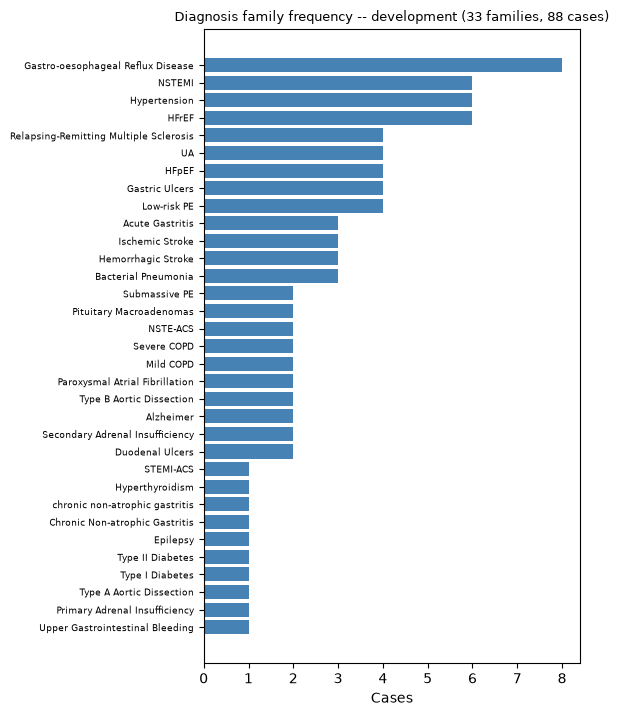

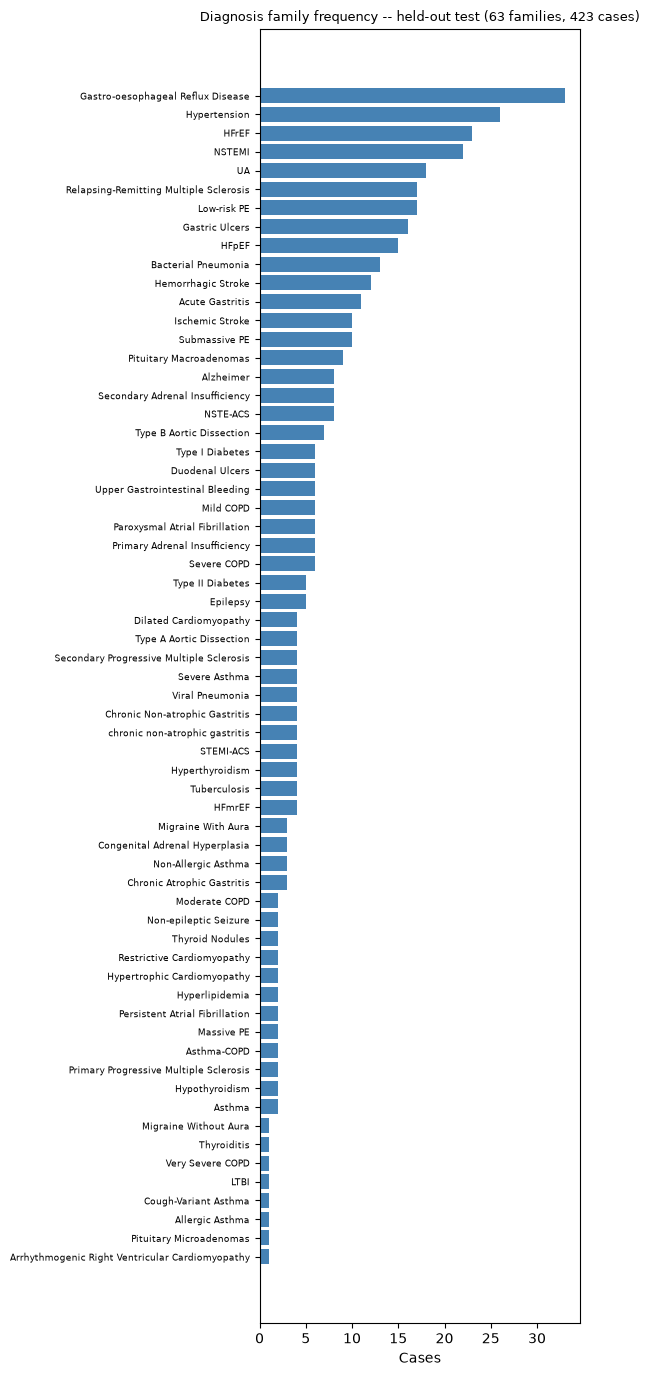

In [17]:
def diagnosis_frequency(cases):
    """Case count per diagnosis family, most frequent first."""
    return pd.Series([case.gold_label for case in cases]).value_counts()


def plot_diagnosis_frequency(cases, partition_name):
    counts = diagnosis_frequency(cases).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(6, max(3, 0.22 * len(counts))))
    ax.barh(counts.index, counts.values, color="steelblue")
    ax.set_xlabel("Cases")
    ax.set_title(
        f"Diagnosis family frequency -- {partition_name} "
        f"({len(counts)} families, {int(counts.sum())} cases)",
        fontsize=9,
    )
    ax.tick_params(axis="y", labelsize=6.5)
    fig.tight_layout()
    return fig


direct_dataset = load_direct_dataset(DIRECT)
development_cases = select_direct_partition(direct_dataset.cases, "development")
test_cases = select_direct_partition(direct_dataset.cases, "test")

for cases, name in ((development_cases, "development"), (test_cases, "held-out test")):
    figure = plot_diagnosis_frequency(cases, name)
    plt.show()

**Analysis**

The development set concentrates on the families with enough cases to stratify
meaningfully; the held-out set carries the long tail, including every family too small
to contribute to development at all. That composition difference, not a weaker method,
is the first place to look if held-out accuracy comes in below development accuracy.


#### 6. Preflight

I run two checks before uploading anything: the test suite, and the sealed package build.
Both are free. A failure in either is a reason not to submit.

In [18]:
returncode, stdout, stderr = run(
    [sys.executable, "-m", "pytest", "-q", "--color=no", "-p", "no:cacheprovider"],
    cwd=REPO, check=False,
)
# pytest -q prints a progress line of dots per test file before its summary. Only the
# summary matters here, so I print the last few non-empty lines rather than the whole
# transcript.
lines = [line for line in stdout.strip().splitlines() if line.strip()]
print("\n".join(lines[-3:]))
TESTS_PASSED = returncode == 0
print("\ntest suite:", "passed" if TESTS_PASSED else "FAILED")


................................ss.s.................................... [ 76%]
...................................................................      [100%]
277 passed, 6 skipped in 44.24s

test suite: passed


##### 6.1 Build the sealed package

`job.prepare` writes three directories under `.hf-runs/<RUN_ID>/`: the executable source
snapshot, the immutable inputs of queries, retrieval index and terminology subset, and an
empty output target. It also records a SHA-256 for every staged file.

In [19]:
returncode, stdout, stderr = run(
    [sys.executable, "-m", "job.prepare"], cwd=REPO, check=False
)
print(stdout or stderr)
PACKAGE_READY = returncode == 0

STAGING = REPO / ".hf-runs" / RUN_ID
if PACKAGE_READY:
    for part in ("source", "input", "output"):
        target = STAGING / part
        count = sum(1 for p in target.rglob("*") if p.is_file())
        print(f"{part:8s} {count:5d} files")

{
  "case_count": 5,
  "phase": "comparison",
  "run_id": "validation-20260817t115053z",
  "scope": "validation",
  "source_files": 45,
  "staging_root": "/Users/oluwatosinoso/Library/CloudStorage/OneDrive-hull.ac.uk/argumentation_schemes/.hf-runs/validation-20260817t115053z",
  "timeout": "2h"
}

source      46 files
input       58 files
output       1 files


##### 6.2 Inspect the package manifests

This is worth reading before spending money. `case_count` confirms the intended sample
size, `query_sha256` confirms the case set, and `umls.raw_rrf_included` confirms that the
raw licensed release is not being uploaded.

In [20]:
source_manifest = json.loads(
    (STAGING / "source/query_runtime_manifest.json").read_text(encoding="utf-8")
)
input_manifest = json.loads(
    (STAGING / "input/query_package_manifest.json").read_text(encoding="utf-8")
)

summary = {
    "run_id": source_manifest["run_id"],
    "scope": source_manifest["scope"],
    "phase": source_manifest["phase"],
    "case_count": input_manifest["case_count"],
    "query_sha256": input_manifest["query_sha256"][:16] + "...",
    "runtime_sha256": source_manifest["runtime_sha256"][:16] + "...",
    "protocol_sha256": source_manifest["protocol_sha256"][:16] + "...",
    "umls_release": input_manifest["umls"]["release"],
    "raw_umls_included": input_manifest["umls"]["raw_rrf_included"],
    "patient_documents_indexed": input_manifest["patient_documents_indexed"],
    "source_files": len(source_manifest["files"]),
}
pd.DataFrame([{"field": k, "value": v} for k, v in summary.items()])

,field,value
0,run_id,validation-20260817t115053z
1,scope,validation
2,phase,comparison
3,case_count,5
4,query_sha256,5637e26929a415a9...
5,runtime_sha256,54ddce75a590c0f9...
6,protocol_sha256,e68b9c6d39c28320...
7,umls_release,2026AA
8,raw_umls_included,False
9,patient_documents_indexed,False


#### 7. Upload and submit — SUBMITTING

The cells in this section spend money. They refuse to act unless `APPROVE_SUBMISSION` is
`True` and the preflight checks above passed.

Cost scales with case count and flavour. An 88-case comparison runs about 40 minutes on
`a100-large`, and a 5-case validation takes a few minutes. There is no automatic retry. An
infrastructure failure stops the run and is recorded, rather than being silently repeated
at cost.

In [21]:
def submission_allowed():
    problems = []
    if not APPROVE_SUBMISSION:
        problems.append("APPROVE_SUBMISSION is False")
    if not TESTS_PASSED:
        problems.append("test suite did not pass")
    if not PACKAGE_READY:
        problems.append("package was not prepared")
    if problems:
        print("submission blocked:")
        for item in problems:
            print("  -", item)
        return False
    return True


if submission_allowed():
    for part in ("source", "input", "output"):
        print("syncing", part)
        run([
            HF_CLI, "buckets", "sync",
            str(STAGING / part),
            f"hf://buckets/{HF_BUCKET}/{RUN_ID}/{part}",
        ], cwd=REPO)
    print("upload complete")

submission blocked:
  - APPROVE_SUBMISSION is False


In [22]:
model_overrides = []
for env_key, value in (
    ("CHAT_MODEL_ID", CHAT_MODEL_ID),
    ("CHAT_MODEL_REVISION", CHAT_MODEL_REVISION),
    ("GENERATOR_MODEL_ID", GENERATOR_MODEL_ID),
    ("GENERATOR_MODEL_REVISION", GENERATOR_MODEL_REVISION),
    ("VERIFIER_MODEL_ID", VERIFIER_MODEL_ID),
    ("VERIFIER_MODEL_REVISION", VERIFIER_MODEL_REVISION),
    ("REASONER_MODEL_ID", REASONER_MODEL_ID),
    ("REASONER_MODEL_REVISION", REASONER_MODEL_REVISION),
    ("JUDGE_MODEL_ID", JUDGE_MODEL_ID),
    ("JUDGE_MODEL_REVISION", JUDGE_MODEL_REVISION),
):
    if value:
        model_overrides += ["--env", f"{env_key}={value}"]
        print("overriding", env_key, "=", value)

if not model_overrides:
    print("no model overrides set; the job uses its pinned defaults")


no model overrides set; the job uses its pinned defaults


In [23]:
JOB_ID = None

if submission_allowed():
    command = [
        HF_CLI, "jobs", "run", "--detach",
        "--name", f"argumentation-{RUN_ID}",
        "--flavor", HF_FLAVOR,
        "--timeout", str(job_config.SCOPES[RUN_SCOPE]["timeout"]),
        "--secrets", "HF_TOKEN",
        "--env", f"RUN_SCOPE={RUN_SCOPE}",
        "--env", f"RUN_PHASE={RUN_PHASE}",
        "--env", f"RUN_ID={RUN_ID}",
        "--env", "PROJECT_ROOT=/workspace/project",
        "--env", "PYTHONPATH=/workspace/project",
        "--env", "QUERY_PACKAGE_ROOT=/workspace/query",
        "--env", f"RUNTIME_SCRATCH_ROOT=/tmp/argumentation-schemes/{RUN_ID}",
        "--env", "OUTPUT_ROOT=/outputs",
        "--env", "VLLM_IPC_ROOT=/tmp/vli",
        *model_overrides,
        "--volume", f"hf://buckets/{HF_BUCKET}/{RUN_ID}/source:/workspace/project:ro",
        "--volume", f"hf://buckets/{HF_BUCKET}/{RUN_ID}/input:/workspace/query:ro",
        "--volume", f"hf://buckets/{HF_BUCKET}/{RUN_ID}/output:/outputs:rw",
        HF_IMAGE,
        "python3", "/workspace/project/job/run.py",
    ]
    _, stdout, _ = run(command, cwd=REPO)
    print(stdout)
    # human-mode `hf jobs run` output has changed shape between huggingface_hub
    # releases -- "id: <id>\nname: ...\nurl: ..." on separate lines in one
    # version, "id=<id> name=... url=..." on a single line in another. Matching
    # either separator, anywhere in the output, is robust to both.
    id_match = re.search(r"\bid[:=]\s*(\S+)", stdout)
    if not id_match:
        raise RuntimeError(f"could not find a job id in the submission output:\n{stdout}")
    JOB_ID = id_match.group(1)
    print("job id", JOB_ID)


submission blocked:
  - APPROVE_SUBMISSION is False


##### 7.1 Monitor

This polls until the job reaches a terminal state. It is safe to interrupt and re-run,
because it reads status rather than changing it.

In [24]:
def poll_job(job_id, interval=120, limit=200):
    for attempt in range(limit):
        _, stdout, _ = run(
            [HF_CLI, "jobs", "inspect", "--format", "json", job_id], check=False
        )
        state = "unknown"
        try:
            state = json.loads(stdout)[0]["status"]["stage"]
        except (json.JSONDecodeError, KeyError, IndexError):
            pass
        stamp = datetime.now(timezone.utc).strftime("%H:%M:%S")
        print(f"{stamp}  {state}")
        if state in {"COMPLETED", "ERROR", "FAILED", "CANCELLED"}:
            return state
        time.sleep(interval)
    return "timeout"


if JOB_ID:
    final_state = poll_job(JOB_ID)
    print("final state", final_state)

##### 7.2 Download the outputs

I download every completed run immediately. Results that exist only in the bucket cannot
be cited, plotted or checked, and a report cannot rest on them.

In [25]:
DOWNLOADS = REPO / "output/hf-downloads" / RUN_ID

if JOB_ID:
    run([
        HF_CLI, "buckets", "sync",
        f"hf://buckets/{HF_BUCKET}/{RUN_ID}/output",
        str(DOWNLOADS),
    ], cwd=REPO)
    print("downloaded to", DOWNLOADS)

#### 8. Load a completed run

Everything below works on any downloaded run, not only one submitted in this session. I
point `ANALYSIS_RUN_ID` at whichever run I want to analyse.

A run directory holds the terminal manifest and audits at the top level, and the per-case
artifacts under `comparison-<scope>/`. Those are `predictions.jsonl` with one row per case
per condition, `argument_traces.jsonl` with one row per case holding the full argumentation
trace, and `adjudications.jsonl`.

In [26]:
# development-20260816t144611z: 88 cases on the current family-first resolver, all
# structural gates pass, zero execution failures. Override with RUN_ID, or with the
# identifier of any downloaded run.
ANALYSIS_RUN_ID = "development-20260816t144611z"

def run_root(run_id):
    return REPO / "output/hf-downloads" / run_id / "runs" / run_id


def comparison_root(run_id):
    root = run_root(run_id)
    candidates = sorted(root.glob("comparison-*"))
    if not candidates:
        raise FileNotFoundError(f"no comparison directory under {root}")
    return candidates[0]


def read_jsonl(path):
    with Path(path).open(encoding="utf-8") as handle:
        return [json.loads(line) for line in handle if line.strip()]


def resolver_id_for(run_id):
    """The resolver identity recorded in a run's terminal manifest, or None."""
    manifest_path = run_root(run_id) / "terminal_manifest.json"
    try:
        manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    except (FileNotFoundError, json.JSONDecodeError):
        return None
    controller = manifest.get("model_roles", {}).get("deterministic_discussion_controller", {})
    return controller.get("resolver_id")


def is_current_architecture(run_id):
    return resolver_id_for(run_id) == CURRENT_ARGUMENT_METHOD.resolver_id


def available_runs(current_architecture_only=True):
    """Downloaded runs with comparison output. `output/hf-downloads` accumulates every
    development-time architecture experiment, not just the frozen method, so this only
    surfaces runs on the current resolver by default."""
    base = REPO / "output/hf-downloads"
    if not base.is_dir():
        return []
    found = []
    for candidate in sorted(base.iterdir()):
        try:
            comparison_root(candidate.name)
        except (FileNotFoundError, OSError):
            continue
        if current_architecture_only and not is_current_architecture(candidate.name):
            continue
        found.append(candidate.name)
    return found


In [27]:
runs = available_runs()
all_runs = available_runs(current_architecture_only=False)
retired_count = len(all_runs) - len(runs)

print(f"{len(runs)} downloaded runs on the current architecture")
for name in runs[-15:]:
    print("  ", name)
if retired_count:
    print(f"\n{retired_count} runs from retired architectures not shown "
          "(available_runs(current_architecture_only=False) lists them)")

24 downloaded runs on the current architecture
   family-first-bounded-20260815t134500z
   family-first-differential-20260815t143000z
   family-first-established-anchor-20260815t171500z
   family-first-evidence-anchor-20260815t150000z
   family-first-incumbent-check-20260815t144500z
   family-first-reproducibility-20260815t140000z
   family-first-reproducibility-20260815t141500z
   test-20260816t163709z
   validation-20260816t045421z
   validation-20260816t052554z
   validation-20260816t055001z
   validation-20260816t061557z
   validation-20260816t065305z
   validation-20260816t130355z
   validation-20260816t141631z

57 runs from retired architectures not shown (available_runs(current_architecture_only=False) lists them)


##### 8.1 Verify the run before using it

A run is usable only if it terminated cleanly, its gates passed, and its recorded decoding
settings match the contract I declared in section 4.1. This check is what turns the
determinism claim into evidence.

In [28]:
def verify_run(run_id):
    """Terminal state, execution failures, structural gates and the decoding settings the
    run actually recorded, checked against DETERMINISM_CONTRACT."""
    root = run_root(run_id)
    manifest = json.loads((root / "terminal_manifest.json").read_text(encoding="utf-8"))
    audit = json.loads((root / "query_execution_audit.json").read_text(encoding="utf-8"))
    structural = json.loads((root / "structural_audit.json").read_text(encoding="utf-8"))
    models = manifest["reproducibility"]["models"]

    def recorded(field):
        """One value when every model role agrees on it, otherwise all of them."""
        values = {model[field] for model in models.values()}
        return values.pop() if len(values) == 1 else sorted(values, key=str)

    checks = [
        ("terminated cleanly", manifest["status"], "completed"),
        ("zero execution failures", audit["case_failure_count"], 0),
        ("structural gates pass", structural["all_gates_pass"], True),
        ("temperature", recorded("temperature"), DETERMINISM_CONTRACT["temperature"]),
        ("seed", recorded("seed"), DETERMINISM_CONTRACT["seed"]),
        ("greedy decoding (top_p, top_k)", (recorded("top_p"), recorded("top_k")), (1, -1)),
        ("sequential requests", manifest["sequential_request_processing"], True),
    ]
    frame = pd.DataFrame([
        {"check": name, "observed": observed, "required": required,
         "pass": observed == required}
        for name, observed, required in checks
    ])
    return manifest, frame


manifest, verification = verify_run(ANALYSIS_RUN_ID)
display(verification)
if not verification["pass"].all():
    print("\nThis run failed one or more checks and should not be reported.")

,check,observed,required,pass
0,terminated cleanly,completed,completed,True
1,zero execution failures,0,0,True
2,structural gates pass,True,True,True
3,temperature,0,0,True
4,seed,17,17,True
5,"greedy decoding (top_p, top_k)","(1, -1)","(1, -1)",True
6,sequential requests,True,True,True


#### 9. Results

##### 9.1 Condition-level accuracy

My primary endpoint is family-level diagnostic accuracy. A prediction counts as correct
when it names the same diagnostic family as the reference label.

Two properties of this metric matter for interpretation. It is produced by a pinned
post-hoc judge model that is evaluation-only and has no influence on any diagnosis. And
because it scores at family level, it does not penalise a coarser answer. A condition that
returns a parent label where the reference is a child still scores as correct. That
asymmetry becomes important in section 9.2.

In [29]:
def load_predictions(run_id):
    """One row per (case, condition) for a downloaded run."""
    return pd.DataFrame(read_jsonl(comparison_root(run_id) / "predictions.jsonl"))


predictions = load_predictions(ANALYSIS_RUN_ID)
print("rows      ", len(predictions))
print("cases     ", predictions["case_id"].nunique())
print("conditions", sorted(predictions["mode"].unique()))
print("\ncolumns:")
print(sorted(predictions.columns.tolist()))

rows       352
cases      88
conditions ['direct', 'evidence_grounded_argumentation', 'flat_rag', 'graph_rag']

columns:
['abstained', 'cache_hit', 'case_id', 'citations', 'dataset', 'error', 'gold_label', 'latency_seconds', 'metadata', 'mode', 'model_id', 'observations', 'predicted_label', 'prompt_hash', 'quality_flags', 'reasoning', 'run_id', 'task', 'valid_evidence_ids']


Accuracy is recomputed from the per-case judge verdicts rather than read from the run's
summary file, so this table and the paired tests in section 9.5 are built from the same
rows.

In [30]:
def judgments_frame(run_id):
    """Family-judge verdicts for a run, with `mode` attached and exclusions dropped.

    clinical_family_judgments.jsonl has no `mode` column of its own. Its rows are
    guaranteed to appear in (case, then CONDITIONS in order) blocks -- the same
    invariant structural_audit.json's `exact_four_main_modes_once_per_case` gate
    checks -- so `mode` is recovered by position within each case rather than
    guessed from a column name that was never there.
    """
    frame = pd.DataFrame(read_jsonl(run_root(run_id) / "clinical_family_judgments.jsonl"))
    frame["mode"] = frame.groupby("case_id").cumcount().map(dict(enumerate(CONDITIONS)))
    return frame[frame["included_in_accuracy"]]


def accuracy_table(run_id):
    frame = judgments_frame(run_id)
    table = frame.groupby("mode")["passed"].agg(correct="sum", n="count")
    table["accuracy"] = table["correct"] / table["n"]
    table = table.reindex([mode for mode in CONDITIONS if mode in table.index])
    table.index = [CONDITION_LABELS[mode] for mode in table.index]
    return table


def scope_case_count(run_id):
    """How many cases the run covered.

    Deliberately not the smallest accuracy denominator: the argumentation condition's
    denominator excludes its abstentions on purpose, so reading it as the scope size
    would make an honest abstention look like a truncated run.
    """
    return int(load_predictions(run_id)["case_id"].nunique())


# The smallest scope meant to be reported rather than smoke-tested.
REPORTING_FLOOR = job_config.SCOPES["development"]["case_count"]

results = accuracy_table(ANALYSIS_RUN_ID)
results["accuracy"] = results["accuracy"].round(4)
results["noise_floor"] = [round(noise_floor(n), 4) for n in results["n"]]

CASE_COUNT = scope_case_count(ANALYSIS_RUN_ID)
TOO_SMALL_TO_REPORT = CASE_COUNT < REPORTING_FLOOR
if TOO_SMALL_TO_REPORT:
    print(f"CAUTION: {ANALYSIS_RUN_ID} covered {CASE_COUNT} cases, below the "
          f"{REPORTING_FLOOR}-case development scope. This is a pipeline smoke test, "
          "not a reportable result.")
else:
    print(f"{ANALYSIS_RUN_ID}: {CASE_COUNT} cases.")

excluded = CASE_COUNT - results["n"]
if (excluded > 0).any():
    print("\nexcluded from the accuracy denominator (abstentions and judge exclusions):")
    for name, count in excluded[excluded > 0].items():
        print(f"  {name}: {count}")
print()
results

development-20260816t144611z: 88 cases.

excluded from the accuracy denominator (abstentions and judge exclusions):
  Argumentation: 3



,correct,n,accuracy,noise_floor
Direct,58,88,0.6591,0.0114
Basic retrieval,58,88,0.6591,0.0114
Graph RAG,61,88,0.6932,0.0114
Argumentation,59,85,0.6941,0.0118


I plot the same table. Every figure goes to `OUTPUT` under a filename that includes the
run identifier, so a figure in the report can always be traced back to the run that
produced it.

saved accuracy_by_condition_development-20260816t144611z.png


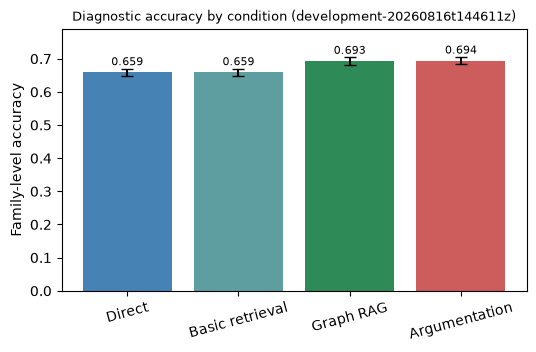

In [31]:
BAR_COLOURS = ["steelblue", "cadetblue", "seagreen", "indianred"]


def save_figure(fig, name, run_id=None):
    path = OUTPUT / f"{name}_{run_id or ANALYSIS_RUN_ID}.png"
    fig.savefig(path, bbox_inches="tight")
    print("saved", path.name)
    return path


def plot_accuracy(table, run_id, caution=False):
    """Accuracy per condition, with the run-to-run noise floor as the error bar."""
    floor = table["noise_floor"].iloc[0]
    fig, ax = plt.subplots(figsize=(6, 3.4))
    ax.bar(table.index, table["accuracy"], color=BAR_COLOURS[: len(table)])
    ax.errorbar(range(len(table)), table["accuracy"], yerr=floor,
                color="black", capsize=4, fmt="none")
    for index, value in enumerate(table["accuracy"]):
        ax.text(index, value + floor + 0.01, f"{value:.3f}", ha="center", fontsize=8)
    ax.set_ylabel("Family-level accuracy")
    ax.set_title(f"Diagnostic accuracy by condition ({run_id})", fontsize=9)
    ax.set_ylim(0, min(1.0, table["accuracy"].max() + 4 * floor + 0.05))
    ax.tick_params(axis="x", rotation=15)
    if caution:
        ax.text(0.5, 1.14, "CAUTION -- pipeline smoke test, not a reportable result",
                transform=ax.transAxes, ha="center", fontsize=8, color="firebrick")
    return fig


figure = plot_accuracy(results, ANALYSIS_RUN_ID, caution=TOO_SMALL_TO_REPORT)
save_figure(figure, "accuracy_by_condition")
plt.show()

**Analysis**

The error bars show the observed run-to-run noise floor, not a sampling confidence
interval. They are there as a reminder that differences of this size are not
interpretable, which is a more useful warning here than a standard error would be.

##### 9.2 Resolver actions: where the argumentation condition actually ends up

The accuracy table does not separate a diagnosis the resolver *established* from one it
*fell back to*. `maintain` and `switch` are the confident outcomes: the resolver reached a
child-level diagnosis on its own cited evidence. `family_fallback` and `protected_incumbent`
each cover two situations that the action name alone hides -- a proposal with valid cited
evidence that simply had no child-level label, and a proposal with no valid supporting
argument at all, kept because the Graph RAG incumbent survived verification. The cell below
splits them on whether the evidence validator challenged the proposal. `abstain` is counted
on its own, since declining to answer is not the same failure as answering wrongly.

In [32]:
CONFIDENT_ACTIONS = {"maintain", "switch"}
FALLBACK_ACTIONS = {"family_fallback", "protected_incumbent"}


def resolution_basis(action, proposal_was_challenged):
    """What a resolver action actually rests on.

    `proposal_was_challenged` is whether the proposed candidate carries a "challenge"
    node in the argument graph, meaning the deterministic evidence validator found no
    valid supporting argument for it. That is what tells the two fallback situations
    apart: a clean pass that is only labelled a fallback because it lacks a child-level
    label, versus a candidate rescued despite having no cited evidence of its own.
    """
    if action in CONFIDENT_ACTIONS:
        return "confident"
    if action == "abstain":
        return "abstain"
    if action in FALLBACK_ACTIONS:
        return "evidence_rescue" if proposal_was_challenged else "clean_pass"
    return "other"


def resolver_actions(run_id):
    """One row per case: the generator's decision, the verifier's attack, and what the
    resolver's action rests on."""
    rows = []
    for trace in read_jsonl(comparison_root(run_id) / "argument_traces.jsonl"):
        dialectical = trace["dialectical_trace"]
        proposal = dialectical["direct_differential"]
        attack = dialectical["attack"]
        action = trace["dialectical_resolution"]["action"]
        challenged = {
            node["candidate_id"]
            for node in trace["argument_graph"]["nodes"]
            if node["node_type"] == "challenge"
        }
        rows.append({
            "case_id": trace["case_id"],
            "resolution_action": action,
            "direct_decision": proposal["decision"],
            "attacked": attack["attack"],
            "attack_type": attack["attack_type"],
            "basis": resolution_basis(action, proposal["candidate_id"] in challenged),
        })
    return pd.DataFrame(rows)

In [33]:
BASIS_ORDER = ["confident", "clean_pass", "evidence_rescue", "abstain", "other"]
BASIS_LABELS = {
    "confident": "Confident (child-level diagnosis)",
    "clean_pass": "Supported (family-level, no child label)",
    "evidence_rescue": "Fallback (no direct support, retained via incumbent)",
    "abstain": "Abstained",
    "other": "Other / unrecognised",
}
LABEL_WIDTH = max(len(label) for label in BASIS_LABELS.values())


def basis_counts(actions):
    """Resolver outcomes in reporting order, dropping any that did not occur."""
    counts = actions["basis"].value_counts()
    return counts.reindex([name for name in BASIS_ORDER if name in counts.index])


def print_basis_counts(counts, cases):
    for name, count in counts.items():
        print(f"{BASIS_LABELS[name]:<{LABEL_WIDTH}}  {count:3d}")
    sound = counts.get("confident", 0) + counts.get("clean_pass", 0)
    fallback = counts.get("evidence_rescue", 0) + counts.get("abstain", 0)
    print(f"\nEstablished on cited evidence: {sound} of {cases} = {sound / cases:.1%}")
    print(f"Fell back or abstained:        {fallback} of {cases} = {fallback / cases:.1%}")


actions = resolver_actions(ANALYSIS_RUN_ID)
counts = basis_counts(actions)
print_basis_counts(counts, len(actions))

Supported (family-level, no child label)               36
Fallback (no direct support, retained via incumbent)   49
Abstained                                               3

Established on cited evidence: 36 of 88 = 40.9%
Fell back or abstained:        52 of 88 = 59.1%


saved resolver_actions_development-20260816t144611z.png


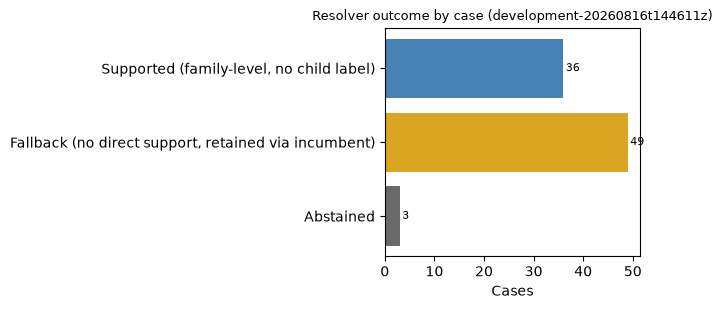

In [34]:
BASIS_COLOURS = {
    "confident": "seagreen",
    "clean_pass": "steelblue",
    "evidence_rescue": "goldenrod",
    "abstain": "dimgray",
    "other": "indianred",
}


def plot_resolver_basis(counts, run_id):
    """Resolver outcome by case, split by what the outcome rests on."""
    fig, ax = plt.subplots(figsize=(6.6, 3.2))
    ax.barh([BASIS_LABELS[name] for name in counts.index], counts.values,
            color=[BASIS_COLOURS[name] for name in counts.index])
    for index, value in enumerate(counts.values):
        ax.text(value + counts.max() * 0.01, index, str(value), va="center", fontsize=8)
    ax.set_xlabel("Cases")
    ax.set_title(f"Resolver outcome by case ({run_id})", fontsize=9)
    ax.invert_yaxis()
    fig.tight_layout()
    return fig


figure = plot_resolver_basis(counts, ANALYSIS_RUN_ID)
save_figure(figure, "resolver_actions")
plt.show()

**Analysis**

No case on this run reached a confident resolution. 36 of the 88 are clean passes (steel
blue), where the proposal carried valid cited evidence but no child-level label; 49 are
evidence rescues (goldenrod), where the proposal had no valid supporting argument and the
Graph RAG incumbent was retained instead; 3 are abstentions (gray), excluded from the
accuracy denominator rather than counted as wrong answers. The condition's accuracy here is
therefore carried largely by the retrieved incumbent rather than by argumentative work, and
section 9.3 shows where that work is lost.

##### 9.3 The generator and verifier stages

If confident resolutions are rare, the cause lies upstream. Three quantities localise it:
what the generator decided, whether the verifier attacked at all, and which kind of attack
it raised when it did.

The last of these is decisive. Only a `better_supported_alternative` attack names a
concrete replacement diagnosis, so only that type can produce a `switch`. Every other
validated attack type routes to abstention or family fallback by design. A run can
therefore have plenty of successful attacks and still never switch.

In [35]:
print("generator decisions")
print(actions["direct_decision"].value_counts().to_string())

print("\nverifier attacked")
print(actions["attacked"].value_counts().to_string())

attacks = actions[actions["attacked"]]
if len(attacks):
    print("\nattack types among", len(attacks), "attacks")
    print(attacks["attack_type"].value_counts().to_string())
    switchable = int((attacks["attack_type"] == "better_supported_alternative").sum())
    print(f"\ncapable of producing a switch: {switchable} of {len(attacks)}")
else:
    print("\nno attacks were raised in this run")

generator decisions
direct_decision
none_of_supplied_candidates    60
diagnosis_supported            24
insufficient                    4

verifier attacked
attacked
False    79
True      9

attack types among 9 attacks
attack_type
explicit_contradiction        5
wrong_subject_or_encounter    2
diagnostic_insufficiency      2

capable of producing a switch: 0 of 9


saved resolution_attrition_development-20260816t144611z.png


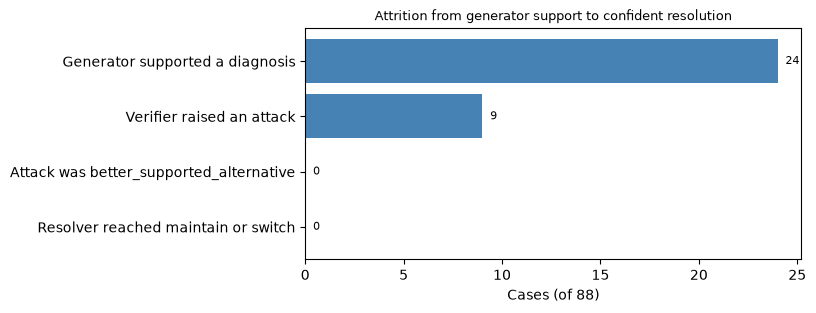

In [36]:
stages = {
    "Generator supported a diagnosis":
        int((actions["direct_decision"] == "diagnosis_supported").sum()),
    "Verifier raised an attack":
        int(actions["attacked"].sum()),
    "Attack was better_supported_alternative":
        int((actions["attack_type"] == "better_supported_alternative").sum()),
    "Resolver reached maintain or switch":
        int(counts.get("confident", 0)),
}

fig, ax = plt.subplots(figsize=(6.4, 3))
ax.barh(list(stages), list(stages.values()), color="steelblue")
for index, value in enumerate(stages.values()):
    ax.text(value + 0.4, index, str(value), va="center", fontsize=8)
ax.set_xlabel(f"Cases (of {len(actions)})")
ax.set_title("Attrition from generator support to confident resolution", fontsize=9)
ax.invert_yaxis()
save_figure(fig, "resolution_attrition")
plt.show()

**Analysis**

The generator supported a diagnosis in 24 of the 88 cases and the verifier raised 9 attacks.
None of the 9 was a `better_supported_alternative`, the only type that names a replacement
diagnosis, so no case could switch and none resolved confidently. The pipeline loses most
cases at the first stage, where the generator rejects every supplied candidate, and the
confident route is closed at the last.

##### 9.4 Does the argumentation condition differ from Graph RAG?

When the resolver retains a protected incumbent it adopts the Graph RAG candidate at family
level, so it is worth asking how much of the argumentation output is simply Graph RAG's
answer. I compare the two by exact label string below, which is a lower bound on agreement:
a parent label and its child are different strings but the same diagnostic family. That
brittleness is also why accuracy is scored by the family-level judge rather than by string
matching. The fallback counts in 9.2 are the better measure of how often the argumentation
condition is resting on the Graph RAG candidate.

In [37]:
def condition_labels(run_id):
    """Predicted label per case, one column per condition."""
    return load_predictions(run_id).pivot_table(
        index="case_id", columns="mode", values="predicted_label", aggfunc="first"
    )


def gold_labels(run_id):
    """Reference diagnosis per case, independent of condition."""
    return load_predictions(run_id).groupby("case_id")["gold_label"].first()


labels = condition_labels(ANALYSIS_RUN_ID).join(gold_labels(ANALYSIS_RUN_ID))
identical = int((labels["graph_rag"] == labels["evidence_grounded_argumentation"]).sum())
print(f"identical label: {identical} of {len(labels)}")
print(f"different label: {len(labels) - identical} of {len(labels)}")

print("\nexamples where they differ:")
differing = labels[labels["graph_rag"] != labels["evidence_grounded_argumentation"]]
display(differing[["gold_label", "graph_rag", "evidence_grounded_argumentation"]].head(12))

identical label: 34 of 88
different label: 54 of 88

examples where they differ:


,gold_label,graph_rag,evidence_grounded_argumentation
case_id,,,
direct-057fbc3184f9,Secondary Adrenal Insufficiency,Primary Adrenal Insufficiency,Adrenal Insufficiency
direct-0f9e5cc3e30e,Epilepsy,Non-epileptic Seizure,Epilepsy
direct-11ea11b9958d,Gastro-oesophageal Reflux Disease,STEMI-ACS,Gastro-oesophageal Reflux Disease
direct-1d161aeb98a0,Low-risk PE,Pulmonary Embolism,Tuberculosis
direct-1d88ff9e2ffb,NSTEMI,NSTEMI,ACS
direct-1e734953f7ca,Duodenal Ulcers,Chronic Gastritis,Gastritis
direct-1ec6885288d8,HFrEF,HFrEF,Heart Failure
direct-22354b733663,Relapsing-Remitting Multiple Sclerosis,Migraine With Aura,Migraine
direct-2671598cd955,NSTEMI,NSTE-ACS,ACS


##### 9.5 Paired comparisons

The four conditions run on the same cases, so I compare them pairwise rather than by
reading the accuracy column. Every case is scored under all four conditions, which makes
the comparison paired and lets me use the cases where two conditions disagree.

I use two tests.

- **Exact McNemar** on the discordant cases. It asks whether the split between "only A was
  right" and "only B was right" is further from even than chance would give.
- **Bootstrap confidence interval** on the accuracy difference, resampling cases with a
  fixed seed so the interval is reproducible.

Six pairs means six tests, so I apply a Holm correction. Without it, one apparent result in
six is roughly what I should expect from noise alone.

In [38]:
def case_correctness(run_id):
    """One row per case, one column per condition, values 1 correct / 0 incorrect."""
    frame = judgments_frame(run_id)
    table = frame.pivot_table(
        index="case_id", columns="mode", values="passed", aggfunc="first"
    )
    return table.dropna().astype(int)


correctness = case_correctness(ANALYSIS_RUN_ID)
print("cases scored under every condition:", len(correctness))
correctness.head()

cases scored under every condition: 85


mode,direct,evidence_grounded_argumentation,flat_rag,graph_rag
case_id,,,,
direct-001d57f71d14,0,1,0,1
direct-057fbc3184f9,0,1,1,1
direct-0f7b5d667d2f,0,0,0,0
direct-0f9e5cc3e30e,1,1,1,1
direct-11ea11b9958d,0,1,1,0


In [39]:
def mcnemar_exact(a, b):
    """Two-sided exact McNemar (statsmodels). Returns (a_only, b_only, p)."""
    a_only = int(((a == 1) & (b == 0)).sum())
    b_only = int(((a == 0) & (b == 1)).sum())
    table = pd.crosstab(a, b).reindex(index=[0, 1], columns=[0, 1], fill_value=0)
    p = mcnemar(table.values, exact=True).pvalue
    return a_only, b_only, p


def bootstrap_difference(a, b, samples=2000, seed=17):
    """Percentile interval for accuracy(b) - accuracy(a), resampling cases (scipy)."""
    def difference(first, second, axis=-1):
        return np.mean(second, axis=axis) - np.mean(first, axis=axis)

    result = bootstrap(
        (np.asarray(a), np.asarray(b)), difference,
        n_resamples=samples, paired=True, method="percentile",
        confidence_level=0.95, random_state=seed,
    )
    return result.confidence_interval.low, result.confidence_interval.high


def holm(p_values):
    """Holm step-down adjustment (statsmodels), preserving input order."""
    return list(multipletests(p_values, method="holm")[1])

In [40]:
def paired_comparisons(run_id):
    correctness = case_correctness(run_id)
    present = [c for c in CONDITIONS if c in correctness.columns]

    rows = []
    for i, first in enumerate(present):
        for second in present[i + 1:]:
            a, b = correctness[first], correctness[second]
            a_only, b_only, p = mcnemar_exact(a, b)
            low, high = bootstrap_difference(a, b)
            rows.append({
                "comparison": f"{CONDITION_LABELS[first]} vs {CONDITION_LABELS[second]}",
                "only_first_correct": a_only,
                "only_second_correct": b_only,
                "difference": round(b.mean() - a.mean(), 4),
                "ci_low": round(low, 4),
                "ci_high": round(high, 4),
                "p_exact": round(p, 4),
            })

    paired = pd.DataFrame(rows)
    paired["p_holm"] = [round(v, 4) for v in holm(paired["p_exact"].tolist())]
    paired["significant"] = paired["p_holm"] < 0.05
    paired["ci_excludes_zero"] = (paired["ci_low"] > 0) | (paired["ci_high"] < 0)
    return paired


paired_comparisons(ANALYSIS_RUN_ID)

,comparison,only_first_correct,only_second_correct,difference,ci_low,ci_high,p_exact,p_holm,significant,ci_excludes_zero
0,Direct vs Basic retrieval,12,11,-0.0118,-0.1176,0.1059,1.0000,1.0,False,False
1,Direct vs Graph RAG,10,12,0.0235,-0.0824,0.1294,0.8318,1.0,False,False
2,Direct vs Argumentation,12,15,0.0353,-0.0824,0.1529,0.7011,1.0,False,False
3,Basic retrieval vs Graph RAG,9,12,0.0353,-0.0706,0.1412,0.6636,1.0,False,False
4,Basic retrieval vs Argumentation,10,14,0.0471,-0.0588,0.1647,0.5413,1.0,False,False
5,Graph RAG vs Argumentation,4,5,0.0118,-0.0588,0.0824,1.0000,1.0,False,False


**Analysis**

On the 85 development cases scored under all four conditions, nothing survives correction:
every `p_holm` is 1.0 and every interval spans zero, so at this sample size the four
conditions are statistically indistinguishable. That is a result, not a missing one. The
discordant counts show why -- the widest split is 12 against 15 -- so the accuracy gaps in
9.1 rest on a handful of cases. Section 12 repeats these tests on the 423 held-out cases,
where two of the comparisons do separate.

saved condition_agreement_development-20260816t144611z.png


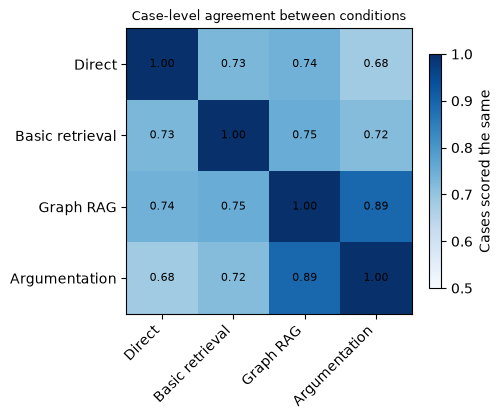

In [41]:
present = [c for c in CONDITIONS if c in correctness.columns]

overlap = pd.DataFrame(
    [[float((correctness[a] == correctness[b]).mean()) for b in present]
     for a in present],
    index=[CONDITION_LABELS[c] for c in present],
    columns=[CONDITION_LABELS[c] for c in present],
).round(3)

fig, ax = plt.subplots(figsize=(4.6, 3.8))
image = ax.imshow(overlap, cmap="Blues", vmin=0.5, vmax=1.0)
ax.set_xticks(range(len(present)), overlap.columns, rotation=45, ha="right")
ax.set_yticks(range(len(present)), overlap.index)
for i in range(len(present)):
    for j in range(len(present)):
        ax.text(j, i, f"{overlap.iloc[i, j]:.2f}", ha="center", va="center",
                fontsize=8, color="black")
ax.set_title("Case-level agreement between conditions", fontsize=9)
fig.colorbar(image, ax=ax, shrink=0.8, label="Cases scored the same")
save_figure(fig, "condition_agreement")
plt.show()

**Analysis**

Agreement is not the same as similar accuracy: two conditions can score alike while
disagreeing case by case. Argumentation and Graph RAG agree on 89% of development cases,
well above any other pair, which is the fallback behaviour of section 9.2 seen from the
outside -- much of the time the argumentation condition is scoring the incumbent's answer.

##### 9.6 Compute cost per condition

No monetary cost is recorded in the run artifacts, so any cost figure here is derived, not
measured. What is recorded is wall-clock runtime and the job flavour, and the per-stage
call structure is known from the architecture. The two retrieval baselines make one
generation call per case, while the argumentation condition adds generator, verifier and
attack-validation calls on top of the same retrieval.

I set `HOURLY_RATE` to the rate actually charged. The table prints its assumption rather
than burying it, because a cost claim without a visible rate is not checkable.

In [42]:
HOURLY_RATE = 2.50        # a100-large, per Hugging Face Jobs pricing
CURRENCY = "USD"


def cost_summary(run_id, hourly_rate=HOURLY_RATE):
    """Wall-clock runtime priced at the assumed hourly rate."""
    root = run_root(run_id)
    manifest = json.loads((root / "terminal_manifest.json").read_text(encoding="utf-8"))
    structural = json.loads((root / "structural_audit.json").read_text(encoding="utf-8"))

    started = datetime.fromisoformat(manifest["started_at"])
    finished = datetime.fromisoformat(manifest["finished_at"])
    minutes = (finished - started).total_seconds() / 60
    cases = structural["counts"]["adjudications"]   # one adjudication per case
    total = minutes / 60 * hourly_rate

    return {
        "run_id": run_id,
        "flavor": HF_FLAVOR,
        "assumed_rate": f"{hourly_rate:.2f} {CURRENCY}/hour",
        "runtime_minutes": round(minutes, 1),
        "cases": cases,
        "estimated_total": round(total, 2),
        "estimated_per_case": round(total / cases, 4),
    }


pd.DataFrame([cost_summary(ANALYSIS_RUN_ID)]).T.rename(columns={0: "value"})

,value
run_id,development-20260816t144611z
flavor,a100-large
assumed_rate,2.50 USD/hour
runtime_minutes,40.8
cases,88
estimated_total,1.7
estimated_per_case,0.0193


The per-condition split below is a structural estimate, not a measurement. All four
conditions execute inside one job, so their costs are not separately billed. The estimate
apportions runtime by the number of model calls each condition requires per case. I treat
it as an order-of-magnitude comparison for the discussion, and I say so in the report.

In [43]:
CALLS_PER_CASE = {
    "direct": 1,
    "flat_rag": 1,
    "graph_rag": 1,
    "evidence_grounded_argumentation": 3,   # generator, verifier, attack validation
}

summary = cost_summary(ANALYSIS_RUN_ID)
total_calls = sum(CALLS_PER_CASE.values())

cost_frame = pd.DataFrame([
    {
        "condition": CONDITION_LABELS[condition],
        "model_calls_per_case": calls,
        "share_of_compute": round(calls / total_calls, 3),
        "apportioned_cost": round(summary["estimated_total"] * calls / total_calls, 2),
    }
    for condition, calls in CALLS_PER_CASE.items()
])
cost_frame["accuracy"] = cost_frame["condition"].map(results["accuracy"])
cost_frame

,condition,model_calls_per_case,share_of_compute,apportioned_cost,accuracy
0,Direct,1,0.167,0.28,0.6591
1,Basic retrieval,1,0.167,0.28,0.6591
2,Graph RAG,1,0.167,0.28,0.6932
3,Argumentation,3,0.500,0.85,0.6941


##### 9.7 Defensibility: what backs an accepted diagnosis

Accuracy alone does not show whether a diagnosis is defensible -- traceable to specific,
checked evidence -- or just a label the model produced. Two structural gates already
computed in section 8.1's audit output speak to this directly:
`candidate_only_or_abstain_with_valid_citations` requires every non-abstained
argumentation decision to select a candidate from the structurally grounded pool, and
`complete_patient_kg_path_source_provenance` requires every one of its citations to carry
a full patient-finding-to-knowledge-graph-node chain. Both pass with zero exceptions on
every downloaded run.

The table below makes the same point at the level of individual predictions.
`citations` for Direct, Basic retrieval and Graph RAG are raw evidence ids the model
chose to list, with no independent check that they support the stated diagnosis. Argumentation's
citations can additionally include a `KFA-`-prefixed id: a specific
patient-finding-to-knowledge-graph-node pairing that passed the argument builder's
critical-question checks (`clinical_cds/argumentation.py`) before being attached to the
candidate. Only argumentation carries this, and only argumentation is structurally
permitted to abstain rather than answer.

In [44]:
def defensibility_summary(run_id):
    """Per condition: answered vs abstained, and of the answered cases, how many
    cite at least one checked evidence binding (a patient-finding-to-knowledge-graph
    pairing that passed critical-question checks, prefixed `KFA-`) rather than only
    a raw, self-reported citation id.
    """
    predictions = load_predictions(run_id)
    rows = []
    for mode in CONDITIONS:
        subset = predictions[predictions["mode"] == mode]
        abstained = int(subset["abstained"].sum())
        accepted = len(subset) - abstained
        typed_binding = int(subset["citations"].apply(
            lambda c: any(str(x).startswith("KFA-") for x in (c or []))
        ).sum())
        rows.append({
            "condition": CONDITION_LABELS[mode],
            "n": len(subset),
            "abstained": abstained,
            "accepted": accepted,
            "accepted_with_typed_binding": typed_binding,
            "typed_binding_rate": round(typed_binding / accepted, 3) if accepted else None,
        })
    return pd.DataFrame(rows).set_index("condition")


defensibility_summary(ANALYSIS_RUN_ID)

,n,abstained,accepted,accepted_with_typed_binding,typed_binding_rate
condition,,,,,
Direct,88,0,88,0,0.000
Basic retrieval,88,0,88,0,0.000
Graph RAG,88,0,88,0,0.000
Argumentation,88,3,85,84,0.988


**Analysis**

Direct, Basic retrieval and Graph RAG never abstain on either downloaded run: they answer
every case, backed only by citations the model chose to list. Argumentation abstains on 3
of 88 development cases and 55 of 423 held-out cases, and of the cases it does answer,
98.8% (development) and 97.8% (held-out) carry at least one checked evidence binding. That
is the practical shape of "defensible": an answer the condition can decline to give, backed
by evidence the pipeline has already checked.

#### 10. Comparing two runs

I evaluate a method change by holding the scope fixed, changing one thing and comparing the
two runs. The pair below shares a bounded 12-case sample, so I read it for mechanism rather
than performance: at 12 cases the noise floor is about 8 percentage points, wide enough to
swallow any accuracy difference these runs could show. The accuracy columns are there to
show that the untouched baselines did not drift; the mechanism counts in the second table
are the result I take from this section. Every other table and figure in this notebook comes
from the 88-case development run or the 423-case held-out run.

In [45]:
def compare_runs(run_a, run_b):
    frames = []
    for label, run_id in (("before", run_a), ("after", run_b)):
        table = accuracy_table(run_id)[["correct", "n", "accuracy"]]
        table.columns = pd.MultiIndex.from_product([[label], table.columns])
        frames.append(table)
    merged = pd.concat(frames, axis=1)
    merged[("change", "accuracy")] = (
        merged[("after", "accuracy")] - merged[("before", "accuracy")]
    )
    merged[("change", "beyond_noise")] = (
        merged[("change", "accuracy")].abs() > merged[("after", "n")].rdiv(1.0)
    )
    return merged.round(4)


# Same 12-case scope on both sides, same resolver. The earlier run abstained on every
# case; the later one resolves normally. The earlier identifier was assigned by hand, so
# it does not match its own start time (2026-08-15T05:32Z in its terminal manifest).
RUN_BEFORE = "family-first-bounded-20260815t000001z"
RUN_AFTER = "family-first-established-anchor-20260815t171500z"

if RUN_BEFORE and RUN_AFTER:
    display(compare_runs(RUN_BEFORE, RUN_AFTER))
else:
    print("set RUN_BEFORE and RUN_AFTER to two downloaded runs on the same scope")

before                  after                change  \
                correct     n accuracy correct   n accuracy accuracy   
Direct              8.0  12.0   0.6667       8  12   0.6667      0.0   
Basic retrieval     9.0  12.0   0.7500       9  12   0.7500      0.0   
Graph RAG           7.0  12.0   0.5833       7  12   0.5833      0.0   
Argumentation       NaN   NaN      NaN       7  12   0.5833      NaN   

                              
                beyond_noise  
Direct                 False  
Basic retrieval        False  
Graph RAG              False  
Argumentation          False

In [46]:
def compare_mechanism(run_a, run_b):
    rows = []
    for label, run_id in (("before", run_a), ("after", run_b)):
        frame = resolver_actions(run_id)
        rows.append({
            "run": label,
            "run_id": run_id,
            "cases": len(frame),
            "generator_supported": int(
                frame["direct_decision"].astype(str)
                .str.contains("diagnosis_supported", case=False).sum()
            ),
            "attacks_raised": int((frame["attacked"] == True).sum()),
            "better_supported_alternative": int(
                frame["attack_type"].astype(str)
                .str.contains("better_supported_alternative", case=False).sum()
            ),
            "confident_resolutions": int(
                frame["resolution_action"].astype(str)
                .str.contains("maintain|switch", case=False, regex=True).sum()
            ),
        })
    return pd.DataFrame(rows).set_index("run")


if RUN_BEFORE and RUN_AFTER:
    display(compare_mechanism(RUN_BEFORE, RUN_AFTER))

,run_id,cases,generator_supported,attacks_raised,better_supported_alternative,confident_resolutions
run,,,,,,
before,family-first-bounded-20260815t000001z,12,0,0,0,0
after,family-first-established-anchor-20260815t171500z,12,5,0,0,0


**Analysis**

Mechanism counts are more informative than accuracy for a change of this kind. An
intervention can move the internal behaviour of the pipeline substantially while leaving
the headline accuracy inside the noise floor. That is a real finding rather than a null
one, provided I report it as a mechanism result and not as a performance result.

#### 11. Export tables and figures for the report

I write every file with the run identifier recorded alongside it. The export manifest is
the link between a number in the report and the run that produced it.


In [47]:
def export_table(frame, name):
    csv_path = OUTPUT / f"{name}_{ANALYSIS_RUN_ID}.csv"
    frame.to_csv(csv_path)
    print("saved", csv_path.name)
    return csv_path


exports = []
exports.append(export_table(results, "accuracy_by_condition"))
exports.append(export_table(
    actions["resolution_action"].value_counts(dropna=False).to_frame("cases"),
    "resolver_actions",
))
exports.append(export_table(cost_frame.set_index("condition"), "compute_cost"))

# RUN_SCOPE belongs to a *new* submission (section 5.2), not to ANALYSIS_RUN_ID, which
# is usually an already-completed run. The scope that produced this run's data is in its
# own comparison-<scope> directory name, so recover it from there.
analysed_scope = comparison_root(ANALYSIS_RUN_ID).name.removeprefix("comparison-")

export_manifest = {
    "run_id": ANALYSIS_RUN_ID,
    "generated_at": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "scope": analysed_scope,
    "cases": int(results["n"].iloc[0]) if not results.empty else None,
    "files": sorted(p.name for p in OUTPUT.glob(f"*{ANALYSIS_RUN_ID}*")),
}

manifest_path = OUTPUT / f"export_manifest_{ANALYSIS_RUN_ID}.json"
manifest_path.write_text(json.dumps(export_manifest, indent=2) + "\n", encoding="utf-8")
print("\n" + json.dumps(export_manifest, indent=2))


saved accuracy_by_condition_development-20260816t144611z.csv
saved resolver_actions_development-20260816t144611z.csv
saved compute_cost_development-20260816t144611z.csv

{
  "run_id": "development-20260816t144611z",
  "generated_at": "2026-08-17T11:52:16+00:00",
  "scope": "development",
  "cases": 88,
  "files": [
    "accuracy_by_condition_development-20260816t144611z.csv",
    "accuracy_by_condition_development-20260816t144611z.png",
    "compute_cost_development-20260816t144611z.csv",
    "condition_agreement_development-20260816t144611z.png",
    "export_manifest_development-20260816t144611z.json",
    "resolution_attrition_development-20260816t144611z.png",
    "resolver_actions_development-20260816t144611z.csv",
    "resolver_actions_development-20260816t144611z.png"
  ]
}


#### 12. Held-out evaluation

The corpus is split deterministically. `select_direct_partition` in `clinical_cds/direct.py`
divides the 511 DiReCT cases with `development_fraction=0.2` and `seed=17`, stratified by
diagnosis label, giving 88 development cases and 423 held-out ones. The split is
development-first: I left the 423 untouched until the method was settled, so nothing was
tuned against them.

One property of it matters for reading the result. A diagnosis with fewer than five cases
contributes none to development, so all of its cases sit in the held-out partition. The
test set therefore contains whole diagnosis families that development never saw, which
makes it a generalisation test rather than a larger sample of the same thing.

The two cells below rebuild the sealed query set and check it against the digest pinned in
`job/config.py`. `build_validation_queries` reads the DiReCT cases and emits, per case, the
sectioned patient evidence, a fixed instruction and the gold label held aside for scoring.
It does no retrieval and touches no GPU; retrieval happens inside the job at run time. The
query records are deterministic, so a rebuild reproduces the same digest. The sealed file
itself is not in the repository -- `output/` is excluded from version control because its
contents derive from the licensed corpus -- so a fresh clone carries the pinned digest and
rebuilds the file from the corpus. Adding the `test` entry to `SCOPES` was a commit rather
than a notebook cell, because it changes the experiment configuration.

In [48]:
BUILD_HELD_OUT_QUERIES = True

if BUILD_HELD_OUT_QUERIES:
    direct = load_direct_dataset(DIRECT)
    development_cases = select_direct_partition(direct.cases, "development")
    test_cases = select_direct_partition(direct.cases, "test")

    print("total cases:      ", len(direct.cases))
    print("development:      ", len(development_cases))
    print("held-out test:    ", len(test_cases))

    development_ids = {case.case_id for case in development_cases}
    test_ids = {case.case_id for case in test_cases}
    assert not (development_ids & test_ids), "partitions must be disjoint"
    assert len(development_ids | test_ids) == len(direct.cases), "partitions must cover"
    print("partitions are disjoint and cover the pool")
else:
    print("set BUILD_HELD_OUT_QUERIES = True to build the held-out query set")

total cases:       511
development:       88
held-out test:     423
partitions are disjoint and cover the pool


In [49]:
if BUILD_HELD_OUT_QUERIES:
    queries = build_validation_queries(direct, [case.case_id for case in test_cases])

    # SCOPES resolves queries_relative against the repository, so the sealed file has to
    # live inside it. This mirrors the development query location.
    TEST_QUERIES_RELATIVE = Path(
        "output/graphrag/microsoft-graphrag-controlled-corpus-v1/"
        "test/sealed-test-queries-v1/test_queries.jsonl"
    )
    target = REPO / TEST_QUERIES_RELATIVE
    target.parent.mkdir(parents=True, exist_ok=True)

    with target.open("w", encoding="utf-8") as handle:
        for record in queries:
            handle.write(json.dumps(record, separators=(",", ":"), sort_keys=True) + "\n")

    digest = sha256_file(target)
    case_ids = sorted(case.case_id for case in test_cases)

    query_manifest = {
        "artifact_id": "msc-v1-test-query-artifact-v1",
        "scope": "test",
        "case_count": len(queries),
        "queries_relative": TEST_QUERIES_RELATIVE.as_posix(),
        "query_sha256": digest,
        "case_ids_sha256": hashlib.sha256(
            "\n".join(case_ids).encode("utf-8")
        ).hexdigest(),
        "partition_seed": 17,
        "development_fraction": 0.2,
        "previous_model_outputs_used": False,
        "raw_content_in_manifest": False,
        "built_at": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    }
    (target.parent / "test_query_manifest.json").write_text(
        json.dumps(query_manifest, indent=2, sort_keys=True) + "\n", encoding="utf-8"
    )

    print(json.dumps(query_manifest, indent=2, sort_keys=True))
    print("\nwritten to", target.relative_to(REPO))
    if digest == job_config.SCOPES["test"]["queries_sha256"]:
        print("digest matches the value pinned in job/config.py")
    else:
        print("MISMATCH: this rebuild does not reproduce the pinned digest")

{
  "artifact_id": "msc-v1-test-query-artifact-v1",
  "built_at": "2026-08-17T11:52:17+00:00",
  "case_count": 423,
  "case_ids_sha256": "dd4e871019d7c6d0b7dc4b14a5d37c58526a324cc782c09bc656d3817b92d7d8",
  "development_fraction": 0.2,
  "partition_seed": 17,
  "previous_model_outputs_used": false,
  "queries_relative": "output/graphrag/microsoft-graphrag-controlled-corpus-v1/test/sealed-test-queries-v1/test_queries.jsonl",
  "query_sha256": "bac9ea39ce67b3657a1bcf72e729e5417501c607f1bcc97008f7de98ed5d6763",
  "raw_content_in_manifest": false,
  "scope": "test"
}

written to output/graphrag/microsoft-graphrag-controlled-corpus-v1/test/sealed-test-queries-v1/test_queries.jsonl
digest matches the value pinned in job/config.py


The `test` entry in `SCOPES` is committed, so the gate below finds the scope present and
the held-out run submits through the same path as every other scope in this notebook.

In [50]:
HELD_OUT_SCOPE = "test"
APPROVE_HELD_OUT = True

def held_out_ready():
    problems = []
    if HELD_OUT_SCOPE not in job_config.SCOPES:
        problems.append(f"no {HELD_OUT_SCOPE!r} entry in job/config.py SCOPES")
    else:
        spec = job_config.SCOPES[HELD_OUT_SCOPE]
        path = REPO / Path(spec["queries_relative"])
        if not path.is_file():
            problems.append(f"sealed query file missing: {path}")
        elif sha256_file(path) != spec["queries_sha256"]:
            problems.append("sealed query digest does not match the pinned value")
    if not APPROVE_HELD_OUT:
        problems.append("APPROVE_HELD_OUT is False")
    return problems


problems = held_out_ready()
if problems:
    print("held-out evaluation is not available:")
    for item in problems:
        print("  -", item)
else:
    print("held-out scope is present and approved")

held-out scope is present and approved


##### 12.1 Method freeze record

This cell records the state of the method at the moment it runs: the commit, whether the
working tree is clean, the protocol hash and the determinism contract.

The record below comes from a later end-to-end pass of the notebook rather than from the
moment the held-out job was submitted, so I read it with two qualifications. The last commit
before the held-out run started was `b9d5d11`, and every commit since then has touched only
this notebook, so the method code the job ran is the code these hashes describe. The working
tree was also modified when the record was taken, which means the commit and protocol hash
are exact but any uncommitted edit at that moment is not captured by them.

The run's own provenance does not depend on this cell. The sealed query set is hash-verified
against its pinned digest above, the run's terminal manifest carries its own reproducibility
fingerprint, and its gates and terminal state are verified in section 8.1.

In [51]:
def method_freeze_record():
    _, commit, _ = run(["git", "rev-parse", "HEAD"], cwd=REPO)
    _, dirty, _ = run(["git", "status", "--porcelain"], cwd=REPO)
    return {
        "frozen_at": datetime.now(timezone.utc).isoformat(timespec="seconds"),
        "commit": commit.strip(),
        "working_tree_clean": not dirty.strip(),
        "protocol_sha256": protocol_sha256(),
        "determinism_contract": DETERMINISM_CONTRACT,
    }


freeze = method_freeze_record()
print(json.dumps(freeze, indent=2))
if not freeze["working_tree_clean"]:
    print("\nWorking tree is modified. Commit before freezing a method for held-out use.")

{
  "frozen_at": "2026-08-17T11:52:17+00:00",
  "commit": "9a20b7b957eceeba6cacf6bca24acade9d9e5643",
  "working_tree_clean": false,
  "protocol_sha256": "e68b9c6d39c2832027042b7af29a861fe786c59eca23a5f58327c1a6b4f9734f",
  "determinism_contract": {
    "temperature": 0,
    "seed": 17,
    "decoding": "greedy",
    "request_ordering": "sequential"
  }
}

Working tree is modified. Commit before freezing a method for held-out use.


##### 12.2 Held-out result

`test-20260816t163709z`: 423 held-out cases, current architecture, all structural gates
pass, zero execution failures. This is the only held-out evaluation this method has had.

In [52]:
HELD_OUT_RUN_ID = "test-20260816t163709z"

held_out_manifest, held_out_verification = verify_run(HELD_OUT_RUN_ID)
display(held_out_verification)

held_out_results = accuracy_table(HELD_OUT_RUN_ID)
held_out_results["accuracy"] = held_out_results["accuracy"].round(4)
held_out_results["noise_floor"] = [round(noise_floor(n), 4) for n in held_out_results["n"]]
held_out_results

,check,observed,required,pass
0,terminated cleanly,completed,completed,True
1,zero execution failures,0,0,True
2,structural gates pass,True,True,True
3,temperature,0,0,True
4,seed,17,17,True
5,"greedy decoding (top_p, top_k)","(1, -1)","(1, -1)",True
6,sequential requests,True,True,True


,correct,n,accuracy,noise_floor
Direct,278,423,0.6572,0.0024
Basic retrieval,281,423,0.6643,0.0024
Graph RAG,307,423,0.7258,0.0024
Argumentation,269,368,0.7310,0.0027


saved accuracy_by_condition_test-20260816t163709z.png


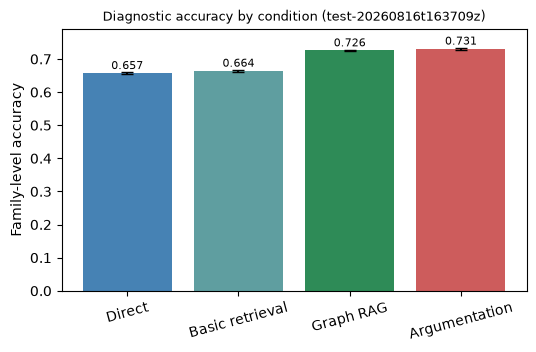

In [53]:
figure = plot_accuracy(held_out_results, HELD_OUT_RUN_ID)
save_figure(figure, "accuracy_by_condition", run_id=HELD_OUT_RUN_ID)
plt.show()

Confident (child-level diagnosis)                       7
Supported (family-level, no child label)              204
Fallback (no direct support, retained via incumbent)  157
Abstained                                              55

Established on cited evidence: 211 of 423 = 49.9%
Fell back or abstained:        212 of 423 = 50.1%
saved resolver_actions_test-20260816t163709z.png


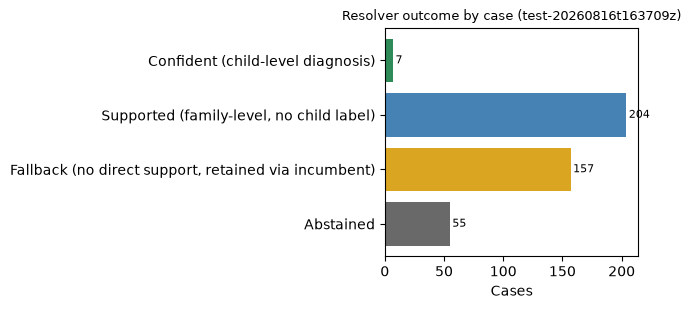

In [54]:
held_out_actions = resolver_actions(HELD_OUT_RUN_ID)
held_out_counts = basis_counts(held_out_actions)
print_basis_counts(held_out_counts, len(held_out_actions))

figure = plot_resolver_basis(held_out_counts, HELD_OUT_RUN_ID)
save_figure(figure, "resolver_actions", run_id=HELD_OUT_RUN_ID)
plt.show()

In [55]:
def scope_comparison(development_run_id, held_out_run_id):
    """Accuracy side by side on the two partitions. Each has its own noise floor,
    since they differ in size (88 vs 423 cases), so no single beyond-noise flag
    applies to both -- read the two noise_floor columns from the tables above.
    """
    development = accuracy_table(development_run_id)[["correct", "n", "accuracy"]]
    development.columns = pd.MultiIndex.from_product([["development"], development.columns])
    held_out = accuracy_table(held_out_run_id)[["correct", "n", "accuracy"]]
    held_out.columns = pd.MultiIndex.from_product([["held_out"], held_out.columns])
    merged = development.join(held_out)
    merged[("change", "accuracy")] = (
        merged[("held_out", "accuracy")] - merged[("development", "accuracy")]
    )
    return merged.round(4)


scope_comparison(ANALYSIS_RUN_ID, HELD_OUT_RUN_ID)

development              held_out                 change
                    correct   n accuracy  correct    n accuracy accuracy
Direct                   58  88   0.6591      278  423   0.6572  -0.0019
Basic retrieval          58  88   0.6591      281  423   0.6643   0.0052
Graph RAG                61  88   0.6932      307  423   0.7258   0.0326
Argumentation            59  85   0.6941      269  368   0.7310   0.0369

In [56]:
# The section 9.5 comparison at held-out scale: up to 423 cases rather than 88, and so
# much tighter intervals on any real difference.
paired_comparisons(HELD_OUT_RUN_ID)

,comparison,only_first_correct,only_second_correct,difference,ci_low,ci_high,p_exact,p_holm,significant,ci_excludes_zero
0,Direct vs Basic retrieval,55,62,0.0190,-0.0380,0.0761,0.5793,1.0000,False,False
1,Direct vs Graph RAG,43,72,0.0788,0.0217,0.1359,0.0087,0.0435,True,True
2,Direct vs Argumentation,41,72,0.0842,0.0272,0.1440,0.0046,0.0276,True,True
3,Basic retrieval vs Graph RAG,34,56,0.0598,0.0109,0.1114,0.0263,0.0944,False,True
4,Basic retrieval vs Argumentation,40,64,0.0652,0.0109,0.1196,0.0236,0.0944,False,True
5,Graph RAG vs Argumentation,13,15,0.0054,-0.0245,0.0353,0.8506,1.0000,False,False


**Analysis**

Both grounded conditions gain on held-out data -- Graph RAG from 0.693 to 0.726 and
Argumentation from 0.694 to 0.731 -- while Direct and Basic retrieval stay where they were.
The held-out partition contains whole diagnosis families development never saw, so this is
evidence against overfitting to development rather than evidence of an improvement.

At 423 cases the paired tests separate what 88 could not: both graph-grounded conditions
beat direct prompting after Holm correction, while Graph RAG and Argumentation remain
indistinguishable from each other. The resolver reaches a confident child-level diagnosis in
7 cases, returns a family-level label on its own cited evidence in 204, retains the Graph
RAG incumbent in 157 and abstains in 55 -- the same shape as development, at five times the
scale.